# 1. Niezbędne importy wraz z konfiguracją GPU oraz Datasetu


In [1]:
import pandas as pd
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torchvision import models, transforms
import time
from tqdm.auto import tqdm
import copy
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Konfiguracja Globalna 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = '/kaggle/input/full-dataset/Dataset_Finalny/'
RESULTS_PATH = '/kaggle/working/results/'
SUPPLEMENTARY_CSV_PATH = '/kaggle/input/wyniki-kompletne/wyniki_visqol_KOMPLETNE.csv'
os.makedirs(RESULTS_PATH, exist_ok=True)

print(f"Używane urządzenie: {device}")
print(f"Wyniki będą zapisywane w: {RESULTS_PATH}")
print(f"Używany plik z dodatkowymi ocenami: {SUPPLEMENTARY_CSV_PATH}")

# Funkcja do wyodrębniania nazwy pliku
def get_filename_from_path(path):
    filename = path.split('\\')[-1]
    filename = filename.split('/')[-1]
    return filename

# Funkcja do uzupełniania ocen
def patch_missing_scores(df_original):
    if not os.path.exists(SUPPLEMENTARY_CSV_PATH):
        print("UWAGA: Nie znaleziono dodatkowego pliku CSV z ocenami. Pominięto krok uzupełniania.")
        return df_original

    print("Próba uzupełnienia brakujących ocen z pliku pomocniczego...")
    df_scores = pd.read_csv(SUPPLEMENTARY_CSV_PATH)
    
    df_original['key_filename'] = df_original['spectrogram_path'].apply(get_filename_from_path)
    
    df_scores.rename(columns={'filename': 'key_filename'}, inplace=True)
    df_scores['key_filename'] = df_scores['key_filename'].str.replace('.mp3', '.npy', regex=False)
    
    df_merged = pd.merge(df_original, df_scores[['key_filename', 'mos_lqo']], on='key_filename', how='left')
    
    initial_nan_count = df_merged['visqol_score'].isna().sum()
    df_merged['visqol_score'] = df_merged['visqol_score'].fillna(df_merged['mos_lqo'])
    final_nan_count = df_merged['visqol_score'].isna().sum()
    
    print(f"Udało się uzupełnić {initial_nan_count - final_nan_count} brakujących ocen.")
    
    df_final = df_merged.drop(columns=['key_filename', 'mos_lqo'])
    return df_final

# Główny proces wczytywania
def load_and_prepare_metadata(data_subset):
    csv_path = os.path.join(BASE_PATH, data_subset, 'metadata.csv')
    df = pd.read_csv(csv_path)
    
    df = patch_missing_scores(df)

    def create_full_path(path):
        filename = get_filename_from_path(path)
        return os.path.join(BASE_PATH, data_subset, 'spectrograms', filename)
    
    df['spectrogram_path'] = df['spectrogram_path'].apply(create_full_path)
    return df
    
def clean_dataframe(df, subset_name):
    initial_rows = len(df)
    df.dropna(subset=['visqol_score'], inplace=True)
    if len(df) < initial_rows:
        print(f"[{subset_name}] Usunięto {initial_rows - len(df)} wierszy z brakującymi etykietami (po próbie uzupełnienia).")
    
    exists_mask = df['spectrogram_path'].apply(os.path.exists)
    num_missing_files = len(df) - exists_mask.sum()
    if num_missing_files > 0:
        print(f"[{subset_name}] Usunięto {num_missing_files} wpisów wskazujących na brakujące pliki spektrogramów.")
    
    cleaned_df = df[exists_mask]
    print(f"[{subset_name}] Ostateczny rozmiar zbioru: {len(cleaned_df)} próbek.")
    return cleaned_df

# Główny proces wczytywania
train_df = clean_dataframe(load_and_prepare_metadata('train'), "Train")
validation_df = clean_dataframe(load_and_prepare_metadata('validation'), "Validation")
test_df = clean_dataframe(load_and_prepare_metadata('test'), "Test")

# Sprawdzenie, czy DataFrame'y nie są puste
if train_df.empty or validation_df.empty or test_df.empty:
    raise ValueError("Jeden lub więcej zbiorów danych (train, validation, test) jest pusty po czyszczeniu. Sprawdź ścieżki do plików.")
else:
    print("\nZbiory danych wczytane i zweryfikowane poprawnie!")

Używane urządzenie: cuda
Wyniki będą zapisywane w: /kaggle/working/results/
Używany plik z dodatkowymi ocenami: /kaggle/input/wyniki-kompletne/wyniki_visqol_KOMPLETNE.csv
Próba uzupełnienia brakujących ocen z pliku pomocniczego...
Udało się uzupełnić 0 brakujących ocen.
[Train] Usunięto 9 wpisów wskazujących na brakujące pliki spektrogramów.
[Train] Ostateczny rozmiar zbioru: 803 próbek.
Próba uzupełnienia brakujących ocen z pliku pomocniczego...
Udało się uzupełnić 0 brakujących ocen.
[Validation] Ostateczny rozmiar zbioru: 159 próbek.
Próba uzupełnienia brakujących ocen z pliku pomocniczego...
Udało się uzupełnić 0 brakujących ocen.
[Test] Ostateczny rozmiar zbioru: 90 próbek.

Zbiory danych wczytane i zweryfikowane poprawnie!


# 2. Przygotowanie klasy MusicDataset wraz ze znormalizowaniem oceny Visqoli pod treningi CNN


In [2]:
min_score = train_df['visqol_score'].min()
max_score = train_df['visqol_score'].max()

class MusicQualityDataset(Dataset):
    def __init__(self, dataframe, min_score, max_score, transforms=None, model_name=""):
        self.df = dataframe
        self.min_score = min_score
        self.max_score = max_score
        self.transforms = transforms
        self.model_name = model_name
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        spectrogram = np.load(row['spectrogram_path']).astype(np.float32)
        
        # Zakładamy, że audio to zazwyczaj zakres -80dB (cisza) do 0dB (max)
        min_db = -80.0
        max_db = 0.0
        
        # Przesunięcie i skalowanie do zakresu -1 - 1
        spectrogram = (spectrogram - min_db) / (max_db - min_db)
        spectrogram = np.clip(spectrogram, 0.0, 1.0) # Ucinamy wszystko co spoza zakresu

        spectrogram_scaled = (spectrogram * 2.0) - 1.0

        spectrogram_tensor = torch.from_numpy(spectrogram_scaled).float().unsqueeze(0)
        
        if self.transforms is not None:
            spectrogram_tensor = self.transforms(spectrogram_tensor)
        
        # Normalizacja wyniku (oceny)
        normalized_score = (row['visqol_score'] - self.min_score) / (self.max_score - self.min_score)
        score_tensor = torch.tensor(normalized_score, dtype=torch.float32)
        
        return spectrogram_tensor, score_tensor

# 3. Utworzenie klasy modeli, które w zależności od przeprowadzanego eksperymentu są uruchamiane

In [3]:
# Ujednolicenie rozmiaru wejściowego (bez zmian)
data_transforms = transforms.Compose([
    transforms.Resize((256, 1876), antialias=True)   # TYLKO 1 kanał
])

print('Zdefiniowano transformacje')

Zdefiniowano transformacje


In [4]:
# --- Model 1: Sieć CNN 1D (bez zmian) ---
class CNN1D_Paper(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=256, out_channels=64, kernel_size=11),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.01),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=7),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.01),
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 230, 256),
            nn.ReLU(),
            nn.Dropout(0.01),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        x = x.squeeze(1)
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

class InceptionV3_Paper(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre_backbone = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=3, kernel_size=11, stride=1, padding=5),
            # Używamy rozmiaru 299x299, bo inaczej Inception rzuca błędem
            transforms.Resize((299, 299), antialias=True) 
        )
        self.backbone = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Podmieniamy ostatnią warstwę
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.pre_backbone(x)
        if self.training:
            outputs, _ = self.backbone(x)
            return outputs
        else:
            return self.backbone(x)

# --- Model 3: VGG19 (architektura 1:1, BEZ poolingu) ---
class VGG19_Paper(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre_conv = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=11, stride=1, padding=5)
        
        # Bierzemy tylko część konwolucyjną
        self.features = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        for param in self.features.parameters():
            param.requires_grad = False
            
        # Dodajemy własną głowę, która zaczyna się od Flatten
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 256), # Wejście 25088
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # Resize jest w DataLoaderze, więc tu go nie ma
        x = self.pre_conv(x)
        x = self.features(x)
        x = self.regressor(x)
        return x


class EfficientNetV2_S_Paper(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre_conv = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=11, stride=1, padding=5)
        
        self.features = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1).features
        for param in self.features.parameters():
            param.requires_grad = False
            
        # Dodajemy własną głowę. Rozmiar wyjścia 'features' to (1280, 12, 12) dla wejścia 384x384
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280 * 12 * 12, 256), # Wejście 62720
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        x = self.pre_conv(x)
        x = self.features(x)
        x = self.regressor(x)
        return x

print("Zdefiniowano architektury 1:1.")

Zdefiniowano architektury 1:1.


In [5]:
def run_experiment(model, model_name, train_loader, validation_loader, test_loader):
    print(f"\n{'='*25} Rozpoczynanie Eksperymentu: {model_name.upper()} {'='*25}")
    
    # Tworzenie dedykowanego folderu na wyniki tego modelu
    model_results_path = os.path.join(RESULTS_PATH, model_name)
    os.makedirs(model_results_path, exist_ok=True)
    
    model = model.to(device)
    
    # Konfiguracja treningu zgodna z artykułem
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, verbose=True)
    
    NUM_EPOCHS = 100
    patience = 20
    patience_counter = 0
    best_val_loss = float('inf')
    best_model_weights = None
    history = {'train_loss': [], 'val_loss': []}

    print("Rozpoczynanie treningu...")
    start_time = time.time()

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        history['train_loss'].append(train_loss / len(train_loader.dataset))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in validation_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
        history['val_loss'].append(val_loss / len(validation_loader.dataset))
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoka {epoch+1:02d}/{NUM_EPOCHS} | Strata tr.: {history['train_loss'][-1]:.4f} | Strata wal.: {history['val_loss'][-1]:.4f} | LR: {current_lr:.1e}")

        scheduler.step(history['val_loss'][-1])
        
        if history['val_loss'][-1] < best_val_loss:
            best_val_loss = history['val_loss'][-1]
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping po epoce {epoch+1}.")
                break
    
    print(f"Trening zakończony w {(time.time() - start_time)/60:.2f} minut.")
    
    if best_model_weights:
        model.load_state_dict(best_model_weights)
        model_path = os.path.join(model_results_path, f"{model_name}_best.pth")
        torch.save(model.state_dict(), model_path)
        print(f"Zapisano najlepszy model w: {model_path}")

    # Zapisywanie wyników i wizualizacji 
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Strata Treningowa')
    plt.plot(history['val_loss'], label='Strata Walidacyjna')
    plt.title(f'Krzywe Uczenia dla {model_name.upper()}')
    plt.xlabel('Epoka')
    plt.ylabel('Strata (MSE)')
    plt.legend()
    plt.savefig(os.path.join(model_results_path, 'learning_curves.png'))
    plt.show()
    
    model.eval()
    all_predictions, all_true_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device);
            outputs = model(inputs)
            
            # Dodajemy .flatten(), aby upewnić się, że ZAWSZE dostajemy 1-wymiarową tablicę
            predictions_np = outputs.squeeze().cpu().numpy().flatten()
            all_predictions.extend(predictions_np)
            
            all_true_labels.extend(labels.cpu().numpy())

    all_predictions = np.array(all_predictions)
    all_true_labels = np.array(all_true_labels)
    
    predictions_denorm = all_predictions * (max_score - min_score) + min_score
    true_labels_denorm = all_true_labels * (max_score - min_score) + min_score
    predictions_denorm = np.clip(predictions_denorm, 1, 5)

    corr, _ = pearsonr(true_labels_denorm, predictions_denorm)
    spearman_corr, _ = spearmanr(true_labels_denorm, predictions_denorm)
    
    rmse = np.sqrt(mean_squared_error(true_labels_denorm, predictions_denorm))
    mae = mean_absolute_error(true_labels_denorm, predictions_denorm)
    r2 = r2_score(true_labels_denorm, predictions_denorm)
    
    results_str = (f"--- Metryki dla {model_name.upper()} ---\n"
                   f"Korelacja Pearsona: {corr:.4f}\n"
                   f"Korelacja Spearmana: {spearman_corr:.4f}\n"
                   f"RMSE: {rmse:.4f}\n"
                   f"MAE: {mae:.4f}\n"
                   f"R^2: {r2:.4f}\n")
    print(results_str)
    with open(os.path.join(model_results_path, 'results.txt'), 'w') as f:
        f.write(results_str)
    print(f"Zapisano metryki w pliku: {os.path.join(model_results_path, 'results.txt')}")

    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=true_labels_denorm, y=predictions_denorm, alpha=0.6)
    plt.plot([1, 5], [1, 5], 'r--', lw=2, label='Idealna predykcja (y=x)')
    plt.xlim(0.8, 5.2); plt.ylim(0.8, 5.2); plt.title("Wykres Rozrzutu"); plt.xlabel("Rzeczywiste Oceny"); plt.ylabel("Przewidziane Oceny"); plt.legend()
    plt.savefig(os.path.join(model_results_path, 'scatter_plot.png'))
    plt.show()
    
    errors = true_labels_denorm - predictions_denorm
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=predictions_denorm, y=errors, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title("Wykres Błędów Resztkowych"); plt.xlabel("Przewidziane Oceny"); plt.ylabel("Błąd (Rzeczywista - Przewidziana)")
    plt.savefig(os.path.join(model_results_path, 'residual_plot.png'))
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.histplot(errors, bins=30, kde=True)
    plt.title("Histogram Błędów Predykcji"); plt.xlabel("Błąd Predykcji")
    plt.savefig(os.path.join(model_results_path, 'errors_histogram.png'))
    plt.show()
    
    print(f"--- Zakończono Eksperyment dla {model_name.upper()} ---")

print("Główna funkcja pipeline'u `run_experiment` została zaktualizowana.")

Główna funkcja pipeline'u `run_experiment` została zaktualizowana.



========================= Rozpoczynanie Eksperymentu: CNN_1D_PAPER =========================
Rozpoczynanie treningu...


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoka 01/100 | Strata tr.: 0.1555 | Strata wal.: 0.0850 | LR: 1.0e-04
Epoka 02/100 | Strata tr.: 0.0862 | Strata wal.: 0.0638 | LR: 1.0e-04
Epoka 03/100 | Strata tr.: 0.0714 | Strata wal.: 0.0669 | LR: 1.0e-04
Epoka 04/100 | Strata tr.: 0.0580 | Strata wal.: 0.0842 | LR: 1.0e-04
Epoka 05/100 | Strata tr.: 0.0526 | Strata wal.: 0.0809 | LR: 1.0e-04
Epoka 06/100 | Strata tr.: 0.0426 | Strata wal.: 0.0967 | LR: 1.0e-04
Epoka 07/100 | Strata tr.: 0.0369 | Strata wal.: 0.0965 | LR: 1.0e-04
Epoka 08/100 | Strata tr.: 0.0319 | Strata wal.: 0.1013 | LR: 1.0e-04
Epoka 09/100 | Strata tr.: 0.0272 | Strata wal.: 0.1016 | LR: 1.0e-04
Epoka 10/100 | Strata tr.: 0.0257 | Strata wal.: 0.0930 | LR: 1.0e-04
Epoka 11/100 | Strata tr.: 0.0179 | Strata wal.: 0.0919 | LR: 5.0e-05
Epoka 12/100 | Strata tr.: 0.0156 | Strata wal.: 0.0860 | LR: 5.0e-05
Epoka 13/100 | Strata tr.: 0.0141 | Strata wal.: 0.1004 | LR: 5.0e-05
Epoka 14/100 | Strata tr.: 0.0136 | Strata wal.: 0.0809 | LR: 5.0e-05
Epoka 15/100 | Strat

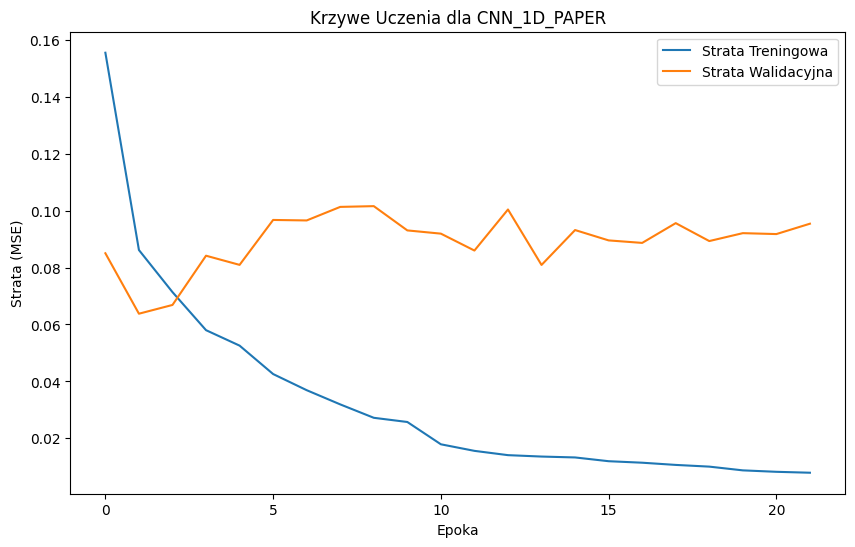

--- Metryki dla CNN_1D_PAPER ---
Korelacja Pearsona: 0.2880
Korelacja Spearmana: 0.2565
RMSE: 1.1068
MAE: 0.9049
R^2: -0.0645

Zapisano metryki w pliku: /kaggle/working/results/cnn_1d_paper/results.txt


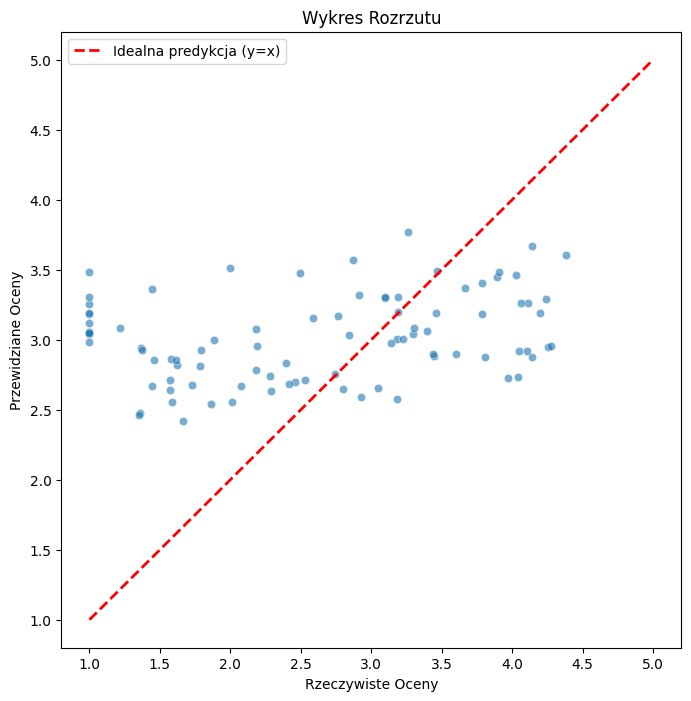

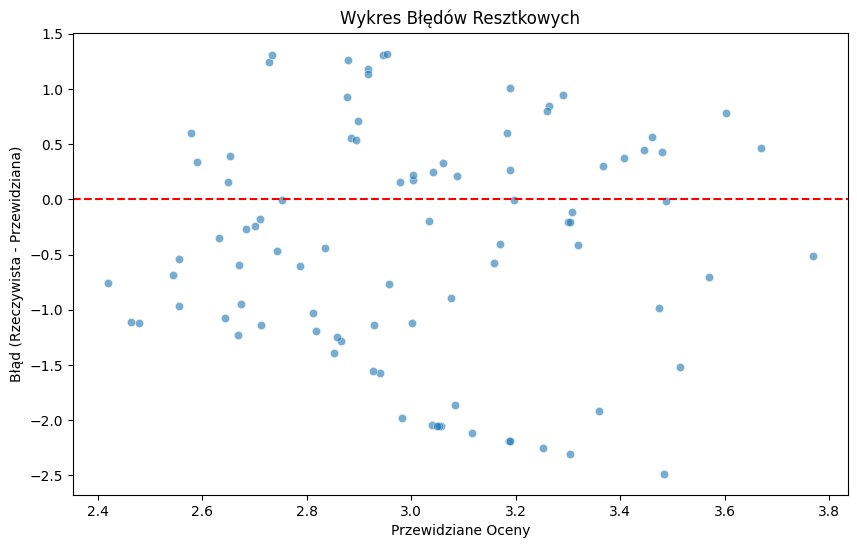

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


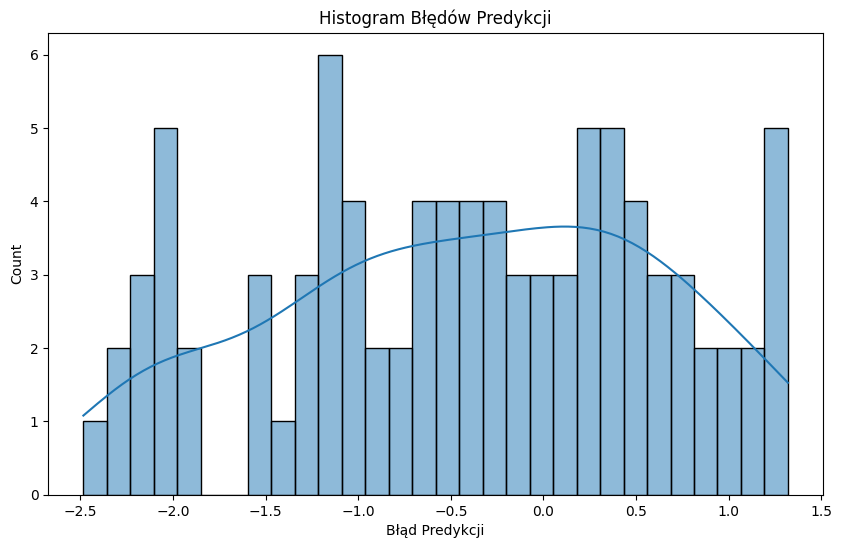

--- Zakończono Eksperyment dla CNN_1D_PAPER ---


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 209MB/s] 
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



========================= Rozpoczynanie Eksperymentu: INCEPTION_V3_PAPER =========================
Rozpoczynanie treningu...
Epoka 01/100 | Strata tr.: 0.1457 | Strata wal.: 0.0790 | LR: 1.0e-04
Epoka 02/100 | Strata tr.: 0.0998 | Strata wal.: 0.0872 | LR: 1.0e-04
Epoka 03/100 | Strata tr.: 0.0888 | Strata wal.: 0.0730 | LR: 1.0e-04
Epoka 04/100 | Strata tr.: 0.0799 | Strata wal.: 0.0675 | LR: 1.0e-04
Epoka 05/100 | Strata tr.: 0.0757 | Strata wal.: 0.0620 | LR: 1.0e-04
Epoka 06/100 | Strata tr.: 0.0670 | Strata wal.: 0.0543 | LR: 1.0e-04
Epoka 07/100 | Strata tr.: 0.0600 | Strata wal.: 0.0526 | LR: 1.0e-04
Epoka 08/100 | Strata tr.: 0.0526 | Strata wal.: 0.0590 | LR: 1.0e-04
Epoka 09/100 | Strata tr.: 0.0534 | Strata wal.: 0.0672 | LR: 1.0e-04
Epoka 10/100 | Strata tr.: 0.0471 | Strata wal.: 0.0598 | LR: 1.0e-04
Epoka 11/100 | Strata tr.: 0.0500 | Strata wal.: 0.0752 | LR: 1.0e-04
Epoka 12/100 | Strata tr.: 0.0475 | Strata wal.: 0.0589 | LR: 1.0e-04
Epoka 13/100 | Strata tr.: 0.0418 

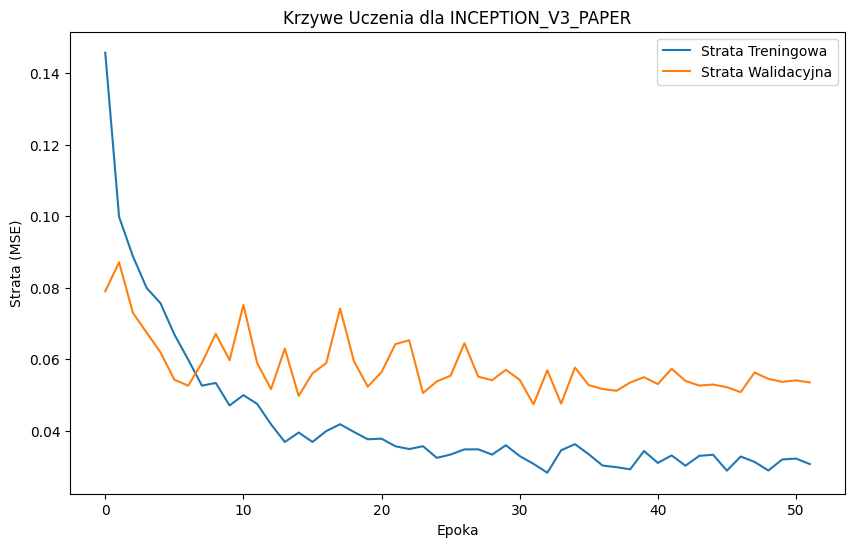

--- Metryki dla INCEPTION_V3_PAPER ---
Korelacja Pearsona: 0.7188
Korelacja Spearmana: 0.7173
RMSE: 0.7615
MAE: 0.5953
R^2: 0.4960

Zapisano metryki w pliku: /kaggle/working/results/inception_v3_paper/results.txt


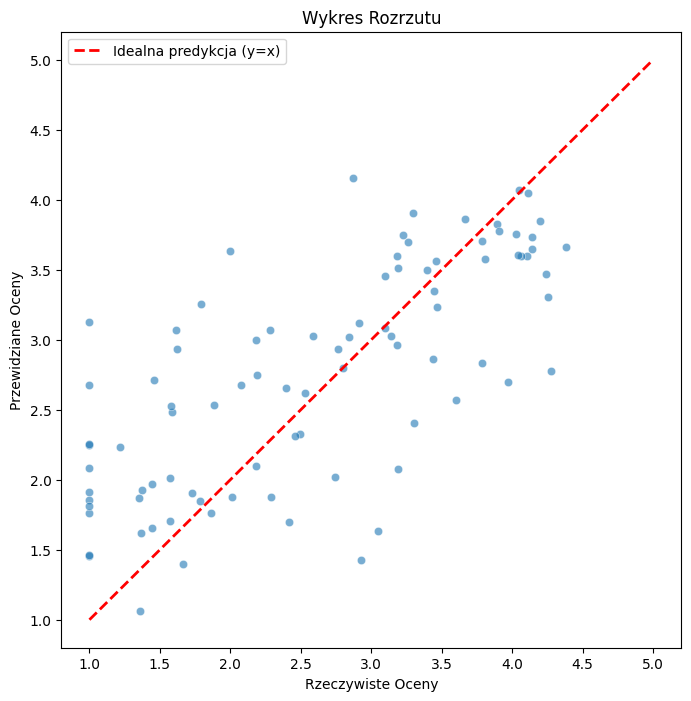

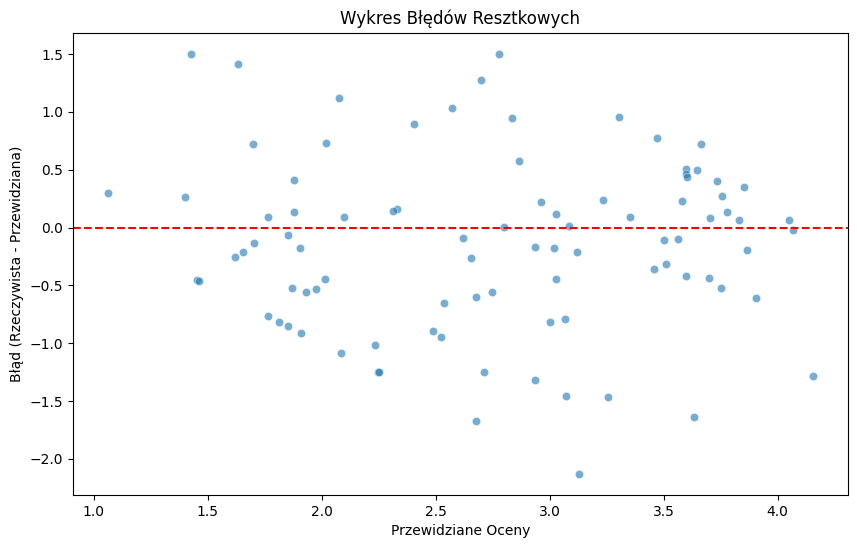

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


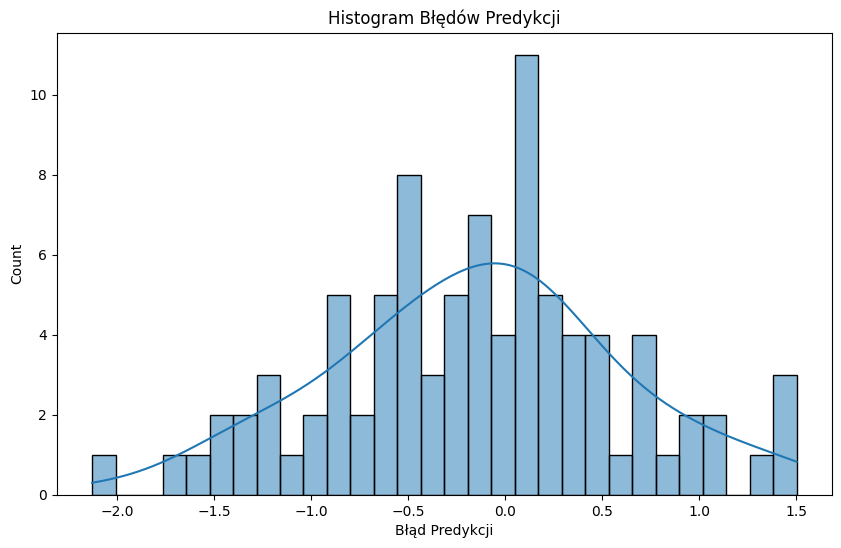

--- Zakończono Eksperyment dla INCEPTION_V3_PAPER ---


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:02<00:00, 207MB/s]



========================= Rozpoczynanie Eksperymentu: VGG19_PAPER =========================
Rozpoczynanie treningu...


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoka 01/100 | Strata tr.: 0.0631 | Strata wal.: 0.0374 | LR: 1.0e-04
Epoka 02/100 | Strata tr.: 0.0175 | Strata wal.: 0.0297 | LR: 1.0e-04
Epoka 03/100 | Strata tr.: 0.0085 | Strata wal.: 0.0352 | LR: 1.0e-04
Epoka 04/100 | Strata tr.: 0.0055 | Strata wal.: 0.0329 | LR: 1.0e-04
Epoka 05/100 | Strata tr.: 0.0048 | Strata wal.: 0.0369 | LR: 1.0e-04
Epoka 06/100 | Strata tr.: 0.0029 | Strata wal.: 0.0312 | LR: 1.0e-04
Epoka 07/100 | Strata tr.: 0.0026 | Strata wal.: 0.0350 | LR: 1.0e-04
Epoka 08/100 | Strata tr.: 0.0017 | Strata wal.: 0.0342 | LR: 1.0e-04
Epoka 09/100 | Strata tr.: 0.0020 | Strata wal.: 0.0317 | LR: 1.0e-04
Epoka 10/100 | Strata tr.: 0.0010 | Strata wal.: 0.0359 | LR: 1.0e-04
Epoka 11/100 | Strata tr.: 0.0007 | Strata wal.: 0.0323 | LR: 5.0e-05
Epoka 12/100 | Strata tr.: 0.0004 | Strata wal.: 0.0333 | LR: 5.0e-05
Epoka 13/100 | Strata tr.: 0.0003 | Strata wal.: 0.0335 | LR: 5.0e-05
Epoka 14/100 | Strata tr.: 0.0002 | Strata wal.: 0.0330 | LR: 5.0e-05
Epoka 15/100 | Strat

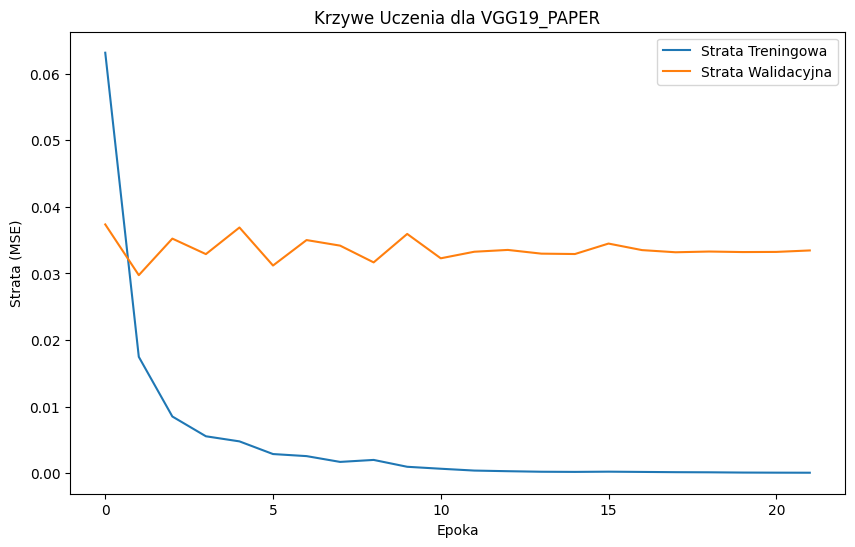

--- Metryki dla VGG19_PAPER ---
Korelacja Pearsona: 0.8054
Korelacja Spearmana: 0.8273
RMSE: 0.6940
MAE: 0.5506
R^2: 0.5814

Zapisano metryki w pliku: /kaggle/working/results/vgg19_paper/results.txt


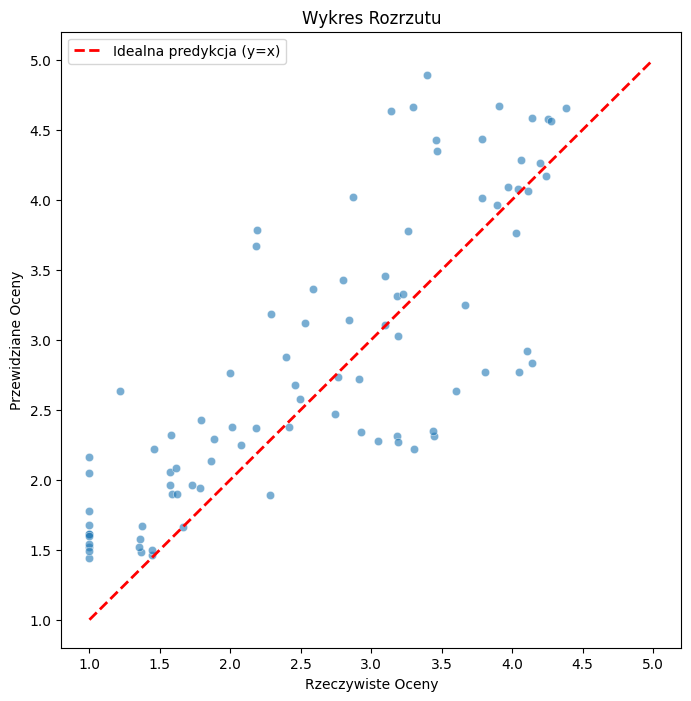

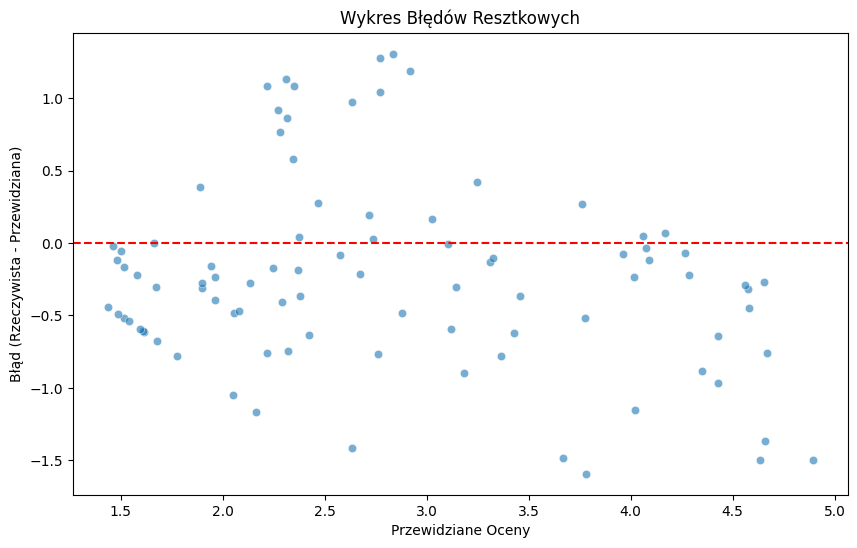

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


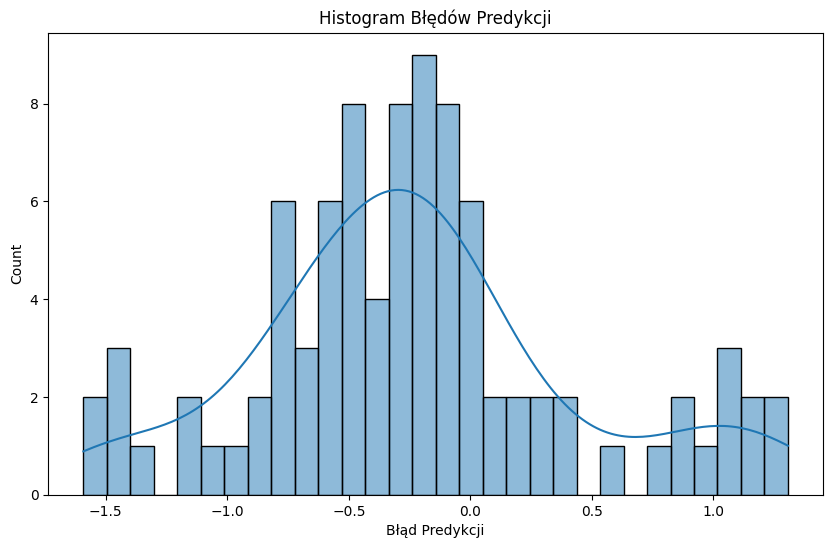

--- Zakończono Eksperyment dla VGG19_PAPER ---


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 206MB/s]



========================= Rozpoczynanie Eksperymentu: EFFICIENTNET_V2_S_PAPER =========================
Rozpoczynanie treningu...


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoka 01/100 | Strata tr.: 0.1478 | Strata wal.: 0.0993 | LR: 1.0e-04
Epoka 02/100 | Strata tr.: 0.0837 | Strata wal.: 0.0737 | LR: 1.0e-04
Epoka 03/100 | Strata tr.: 0.0807 | Strata wal.: 0.0742 | LR: 1.0e-04
Epoka 04/100 | Strata tr.: 0.0560 | Strata wal.: 0.0856 | LR: 1.0e-04
Epoka 05/100 | Strata tr.: 0.0505 | Strata wal.: 0.0861 | LR: 1.0e-04
Epoka 06/100 | Strata tr.: 0.0646 | Strata wal.: 0.0785 | LR: 1.0e-04
Epoka 07/100 | Strata tr.: 0.0545 | Strata wal.: 0.0759 | LR: 1.0e-04
Epoka 08/100 | Strata tr.: 0.0459 | Strata wal.: 0.0780 | LR: 1.0e-04
Epoka 09/100 | Strata tr.: 0.0481 | Strata wal.: 0.0907 | LR: 1.0e-04
Epoka 10/100 | Strata tr.: 0.0474 | Strata wal.: 0.0918 | LR: 1.0e-04
Epoka 11/100 | Strata tr.: 0.0545 | Strata wal.: 0.0705 | LR: 5.0e-05
Epoka 12/100 | Strata tr.: 0.0314 | Strata wal.: 0.0676 | LR: 5.0e-05
Epoka 13/100 | Strata tr.: 0.0274 | Strata wal.: 0.0654 | LR: 5.0e-05
Epoka 14/100 | Strata tr.: 0.0253 | Strata wal.: 0.0693 | LR: 5.0e-05
Epoka 15/100 | Strat

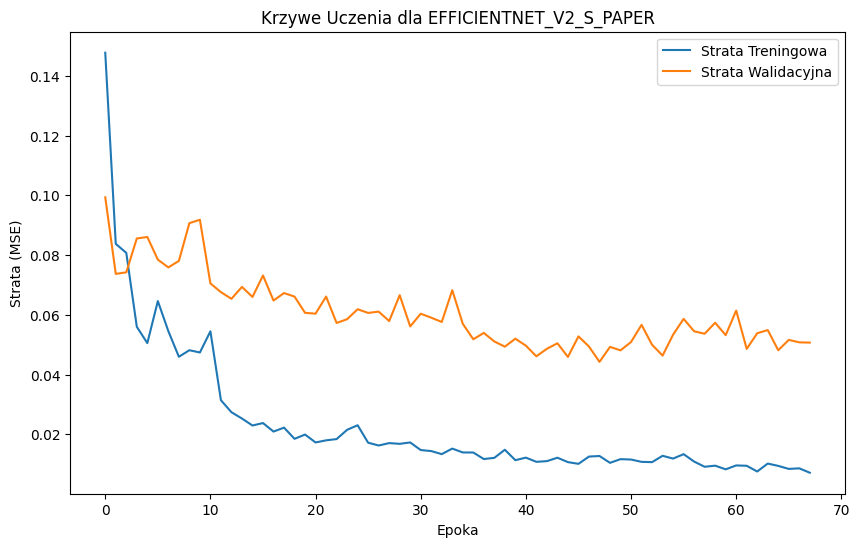

--- Metryki dla EFFICIENTNET_V2_S_PAPER ---
Korelacja Pearsona: 0.7905
Korelacja Spearmana: 0.7747
RMSE: 0.6614
MAE: 0.5168
R^2: 0.6198

Zapisano metryki w pliku: /kaggle/working/results/efficientnet_v2_s_paper/results.txt


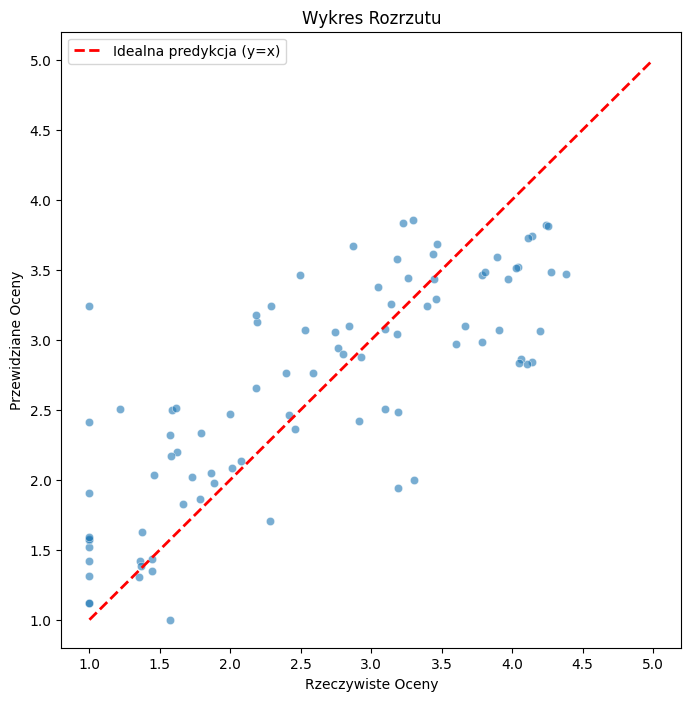

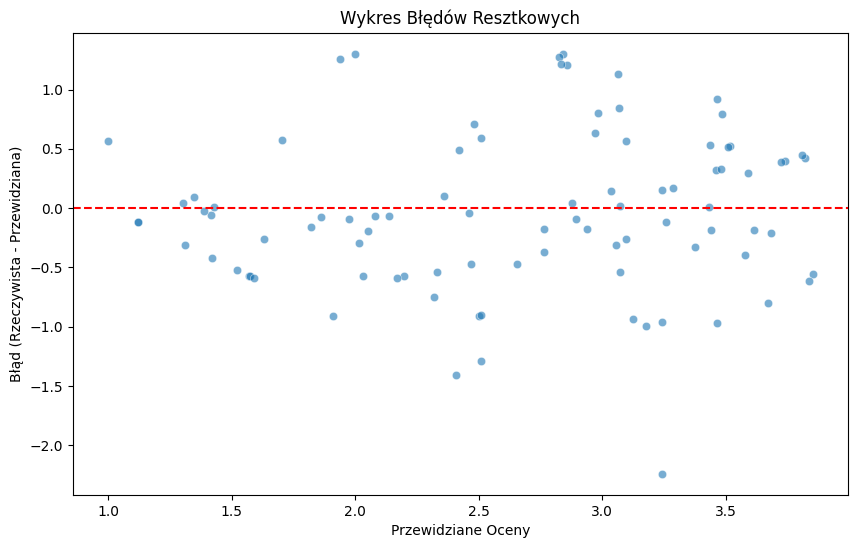

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


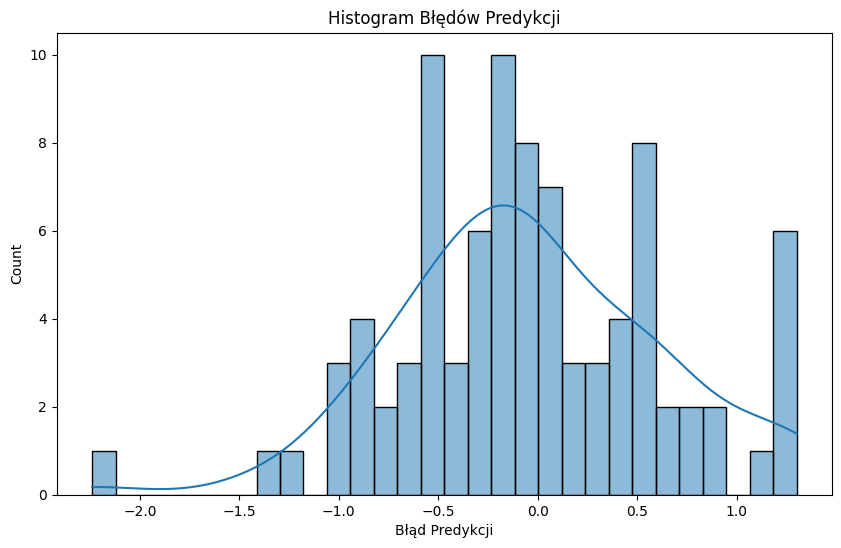

--- Zakończono Eksperyment dla EFFICIENTNET_V2_S_PAPER ---


Wszystkie zaplanowane eksperymenty zostały zakończone.


In [6]:
models_to_run = {
    'cnn_1d_paper': {
        'factory': lambda: CNN1D_Paper(),
        'batch_size': 64,
        'input_size': 1876 # Szerokość dla resize
    },
    'inception_v3_paper': {
        'factory': lambda: InceptionV3_Paper(),
        'batch_size': 64,
        'input_size': 299 # Optymalny rozmiar dla Inception
    },
    'vgg19_paper': {
         'factory': lambda: VGG19_Paper(),
         'batch_size': 32,
        'input_size': 224 # Optymalny rozmiar dla VGG
    },
    'efficientnet_v2_s_paper': {
        'factory': lambda: EfficientNetV2_S_Paper(),
        'batch_size': 16,
        'input_size': 384 # Może być też 384, ale 224 jest OK
    }
}

# Główna pętla, która iteruje po wybranych modelach.
for name, config in models_to_run.items():
    model = config['factory']()

     #DataLoadery z DYNAMICZNYMI transformacjami
    input_size = config['input_size']
    
    if name == 'cnn_1d_paper':
        # Specjalne transformacje dla CNN 1D (tylko resize w osi czasu)
        current_transforms = transforms.Compose([
            transforms.Resize((256, 1876), antialias=True)
        ])
    else:
        # Transformacje dla modeli 2D
        current_transforms = transforms.Compose([
            transforms.Resize((input_size, input_size), antialias=True)
        ])

    # Tworzenie zbiorów danych
    train_dataset = MusicQualityDataset(train_df, min_score, max_score, transforms=current_transforms)
    validation_dataset = MusicQualityDataset(validation_df, min_score, max_score, transforms=current_transforms)
    test_dataset = MusicQualityDataset(test_df, min_score, max_score, transforms=current_transforms)

    # DataLoadery z odpowiednim batch_size
    batch_size = config['batch_size']
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    # pełny eksperyment
    run_experiment(model, name, train_loader, validation_loader, test_loader)

print("\n\nWszystkie zaplanowane eksperymenty zostały zakończone.")